In [1]:
from pathlib import Path
from funman.api.run import Runner

# %load_ext autoreload
# %autoreload 2

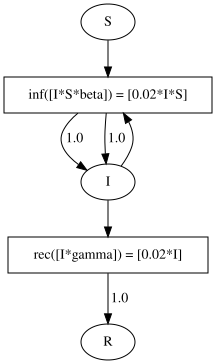

In [ ]:
# Setup Paths
RESOURCES = Path("../resources").resolve()
EXAMPLE_DIR = RESOURCES / "amr" / "petrinet" / "terrarium-tests"
MODEL_PATH = EXAMPLE_DIR / "sir.json"
REQUEST_PATH = EXAMPLE_DIR / "sir_request.json"

runner = Runner()
(model,_) = runner.get_model(str(MODEL_PATH))

In [ ]:
# This cell will run FUNMAN on several scaled versions of a parameter space, and may take a long time.
# This was used to compare results for two versions of dreal, corresponding to the sha: 
# b46e45dbd38f739889a629168851e6d050448275 (Phase 1) and acc5a255e0245f05458b1041a4e163c11e89880e (Phase 2)
# Running the update-dreal script will build dreal and the associated python bindings.  
# Following the build, restarting the kernel will allow this code to run with the respective version.

import os
from funman.server.query import FunmanWorkRequest
import json


scale = 1
scales = [-0.99, -0.75, -0.5, -0.25, -0.1, 0, 0.1, 0.25, 0.5, 0.75, 0.99]

suffix = "phase2"
for pscale in scales:
    if os.path.exists(f"./out/sir_{pscale}_{suffix}.json"):
        print(f"Skipping {pscale}")
        continue
    # pscale = -0.99

    with open(REQUEST_PATH, "r") as request:
        funman_request: FunmanWorkRequest = FunmanWorkRequest.model_validate(json.load(request))
    [beta, gamma, S0, I0, R0 ] = funman_request.parameters
    for p in [beta, gamma]:
        # Add 100 *p % to the parameter width
        # keep beta > 0.095 and gamma < 0.023
        original_width = float(p.interval.width())
        width_diff = original_width*pscale
       
        if p == beta:
            min_upper_beta = 0.0985
            
            # minimum upper bound is 0.095, find upper bound, and set lower 
            if p.interval.ub + 0.5*width_diff < min_upper_beta:
                p.interval.ub = min_upper_beta
            else:
                p.interval.ub += 0.5*width_diff
            p.interval.lb = p.interval.ub - (original_width + width_diff)
            assert p.interval.lb > 0, f"Beta lb is not positive: {p.interval.lb}"
                
        if p == gamma:
            min_lower_gamma = 0.0205
            # maximum lower bound is 0.023, find lower, and set upper
            if p.interval.lb - 0.5*width_diff > min_lower_gamma:
                p.interval.lb = min_lower_gamma
            else:
                p.interval.lb -= 0.5*width_diff
            p.interval.ub = p.interval.lb + original_width+width_diff
        

        

        
    funman_request.config.tolerance *= (1.0-pscale)
    print(f"Tolerance: {funman_request.config.tolerance}")

    funman_request.config.verbosity = 20

    results = Runner().run(MODEL_PATH, funman_request, description="Basic SIR with simple request", case_out_dir="./out", dump_plot=False)
    os.rename(f"./out/{results.id}.json", f"./out/sir_{pscale}_{suffix}.json")

2025-04-25 22:11:37,076 - funman.representation.interval - WARNING - [0.99000, 0.99000) has equal lower and upper bounds, so assuming the upper bound is closed.  (I.e., [lb, ub) is actually [lb, ub])
2025-04-25 22:11:37,089 - funman.representation.interval - WARNING - [0.01000, 0.01000) has equal lower and upper bounds, so assuming the upper bound is closed.  (I.e., [lb, ub) is actually [lb, ub])
2025-04-25 22:11:37,107 - funman.representation.interval - WARNING - [0.00000, 0.00000) has equal lower and upper bounds, so assuming the upper bound is closed.  (I.e., [lb, ub) is actually [lb, ub])


2025-04-25 22:11:37,233 - funman.server.worker - INFO - FunmanWorker running...
2025-04-25 22:11:37,304 - funman.server.worker - INFO - Starting work on: c71b4ae4-6a02-49f3-86ba-29daf54ec7fd


name='beta' interval={'lb': 0.09830000000000001, 'ub': 0.0985, 'closed_upper_bound': False, 'original_width': 0.020000000000000007, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='gamma' interval={'lb': 0.0205, 'ub': 0.0206, 'closed_upper_bound': False, 'original_width': 0.010000000000000002, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
Tolerance: 0.03980000000000001
name='S0' interval={'lb': 0.9900000000000001, 'ub': 0.9900000000000001, 'closed_upper_bound': True, 'original_width': 0.0, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='I0' interval={'lb': 0.01, 'ub': 0.01, 'closed_upper_bound': True, 'original_width': 0.0, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='R0' interval={'lb': 0.0, 'ub': 0.0, 'closed_upper_bound': True, 'original_width': 0.0, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} lab

2025-04-25 22:11:39,308 - funman.api.run - INFO - Dumping results to ./out/c71b4ae4-6a02-49f3-86ba-29daf54ec7fd.json
2025-04-25 22:11:49,402 - funman.api.run - INFO - Dumping results to ./out/c71b4ae4-6a02-49f3-86ba-29daf54ec7fd.json
2025-04-25 22:11:59,484 - funman.api.run - INFO - Dumping results to ./out/c71b4ae4-6a02-49f3-86ba-29daf54ec7fd.json
2025-04-25 22:12:09,552 - funman.api.run - INFO - Dumping results to ./out/c71b4ae4-6a02-49f3-86ba-29daf54ec7fd.json
2025-04-25 22:12:19,628 - funman.api.run - INFO - Dumping results to ./out/c71b4ae4-6a02-49f3-86ba-29daf54ec7fd.json
2025-04-25 22:12:28,635 - funman.search.box_search - INFO - progress: 0.09091
2025-04-25 22:12:28,996 - funman.search.box_search - INFO - progress: 0.18182
2025-04-25 22:12:29,395 - funman.search.box_search - INFO - progress: 0.27273
2025-04-25 22:12:29,705 - funman.search.box_search - INFO - progress: 0.36364
2025-04-25 22:12:30,000 - funman.search.box_search - INFO - progress: 0.45455
2025-04-25 22:12:30,529 -

Skipping -0.75
Skipping -0.5
Skipping -0.25
Skipping -0.1
Skipping 0
Skipping 0.1
Skipping 0.25
Skipping 0.5
Skipping 0.75
name='beta' interval={'lb': 0.0701, 'ub': 0.10990000000000001, 'closed_upper_bound': False, 'original_width': 0.020000000000000007, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='gamma' interval={'lb': 0.01505, 'ub': 0.03495000000000001, 'closed_upper_bound': False, 'original_width': 0.010000000000000002, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
Tolerance: 0.00019999999999999798
name='S0' interval={'lb': 0.9900000000000001, 'ub': 0.9900000000000001, 'closed_upper_bound': True, 'original_width': 0.0, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='I0' interval={'lb': 0.01, 'ub': 0.01, 'closed_upper_bound': True, 'original_width': 0.0, 'normalized': False, 'unnormalized_lb': None, 'unnormalized_ub': None} label='all'
name='R0' interval={'lb': 0

2025-04-25 22:12:42,049 - funman.server.worker - INFO - Starting work on: 308e9f50-6ea8-4181-87fe-c9f631482e99
2025-04-25 22:12:44,059 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:12:54,135 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:13:04,240 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:13:14,309 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:13:24,395 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:13:34,484 - funman.api.run - INFO - Dumping results to ./out/308e9f50-6ea8-4181-87fe-c9f631482e99.json
2025-04-25 22:13:35,340 - funman.search.box_search - INFO - progress: 0.09091
2025-04-25 22:13:35,699 - funman.search.box_search - INFO - progress: 0.18182
2025-04-25 22:13:36,027 - funma